# Surface Reconstruction from Point Clouds (Open3D)

In this notebook, a how to turn a raw point cloud into a 3D mesh using two popular algorithms will be demonstrated:
1. **Poisson Surface Reconstruction** produces smooth, watertight surfaces.
2. **Ball Pivoting Algorithm (BPA)** better preserves fine details, works for partial scans.

Dataset: Open3D's built-in **BunnyMesh** (Stanford Bunny).

In [46]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

In [47]:
def mesh_smoothness(mesh):
    mesh.compute_triangle_normals()
    normals = np.asarray(mesh.triangle_normals)
    
    # Compute dot product between consecutive normals
    dot_products = np.einsum('ij,ij->i', normals[:-1], normals[1:])
    dot_products = np.clip(dot_products, -1.0, 1.0)
    
    # Convert to angles (radians) and then to degrees
    angles = np.degrees(np.arccos(dot_products))
    
    # Smoothness metric: 1 - normalized mean angle
    smoothness = 1 - (np.mean(angles) / 90)  # 0° diff = 1.0, 90° diff = 0.0
    return round(smoothness, 3)


## Step 1: Load Dataset & Visualize

In [45]:
# Load example bunny point cloud
pcd = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(pcd.path)
mesh.compute_vertex_normals()

# Visualize original mesh
o3d.visualization.draw_geometries([mesh])

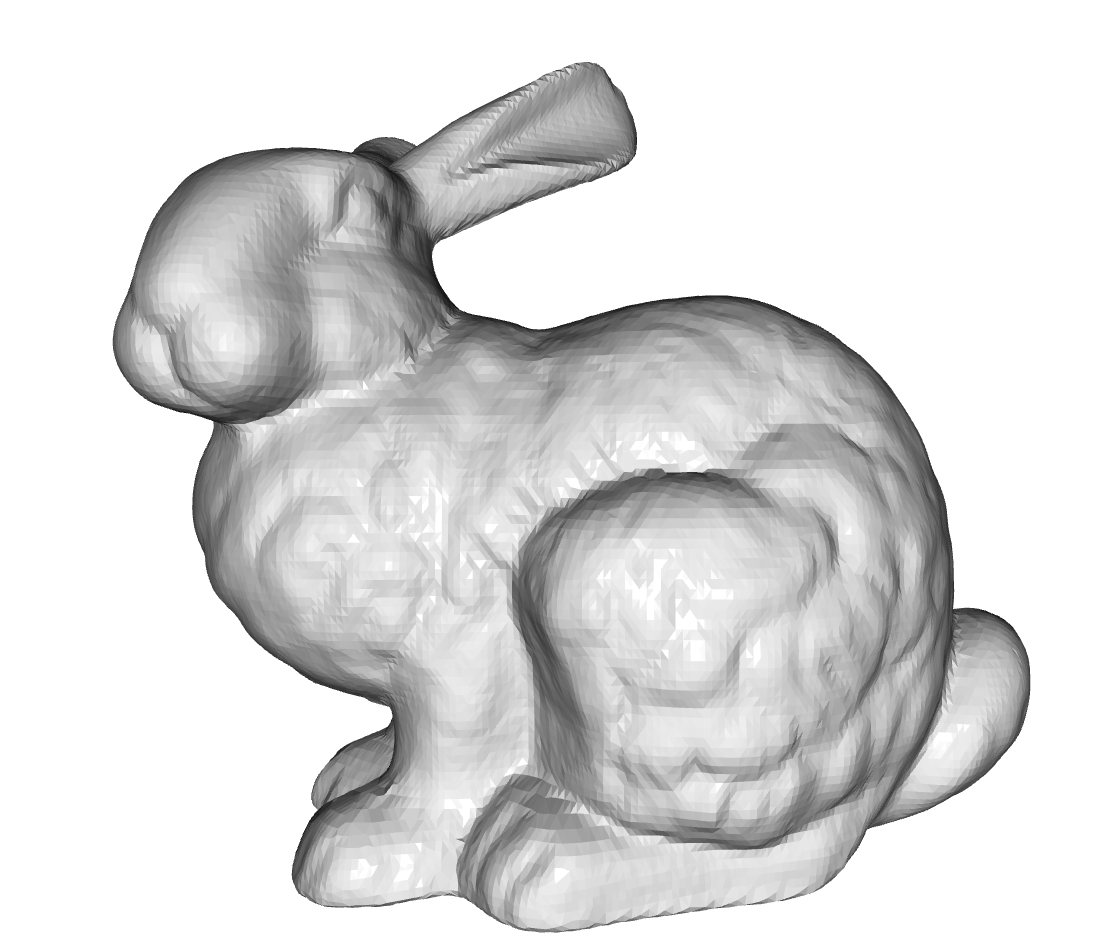

In [48]:
Image(filename="original_mesh.png")

#### Explanation:
We start from a high-quality mesh, then convert it into a point cloud to simulate a scanned object.

## Step 2: Sample Points from Mesh

In [49]:
# Convert mesh to a point cloud
pcd = mesh.sample_points_poisson_disk(3000)  # 3000 points
o3d.visualization.draw_geometries([pcd], window_name="Sampled Point Cloud")

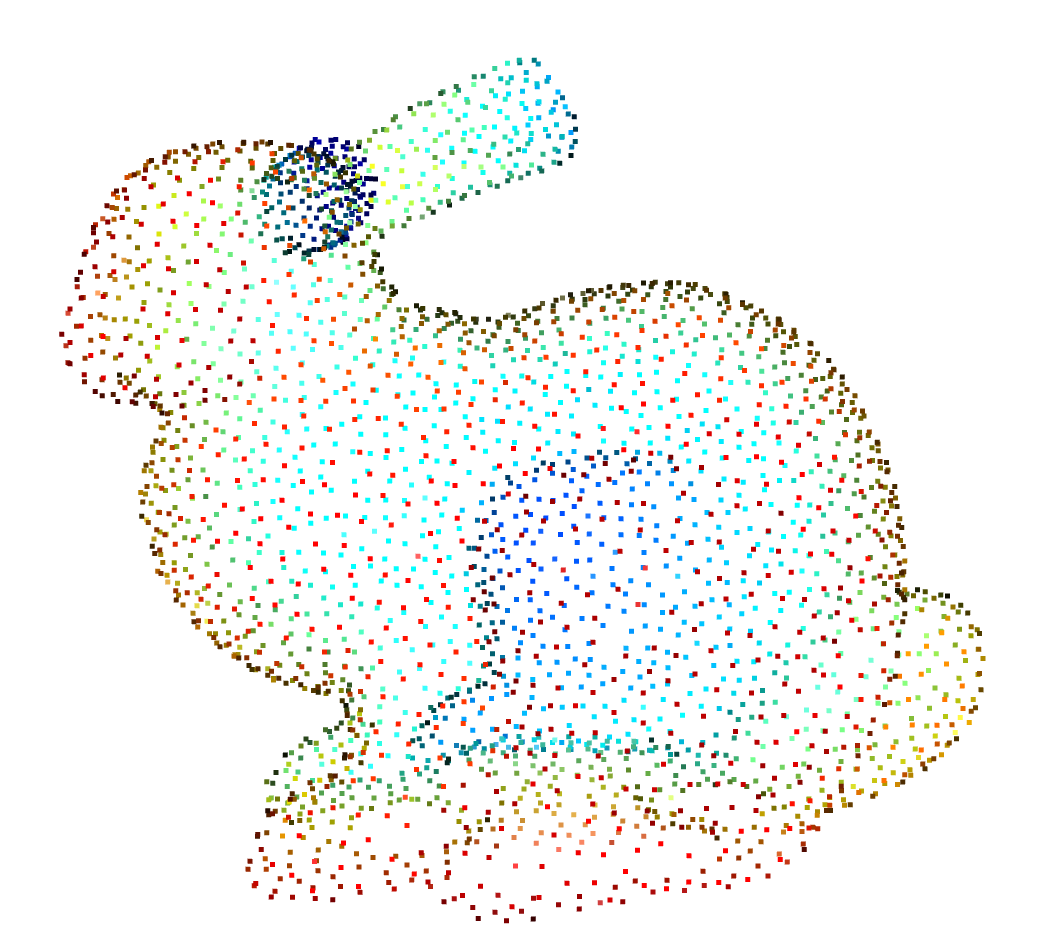

In [50]:
Image(filename="point_cloud.png")

#### Explanation:
Most real-world 3D data comes as point clouds (from LiDAR, depth cameras) as an example here 3000 points.
this was símulated by sampling points from the mesh.

## Step 4: Poisson Reconstruction

In [51]:
# Poisson surface reconstruction
poisson_mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd, depth=8
)

print(poisson_mesh)
o3d.visualization.draw_geometries([poisson_mesh], window_name="Poisson Reconstruction")


TriangleMesh with 10275 points and 20546 triangles.


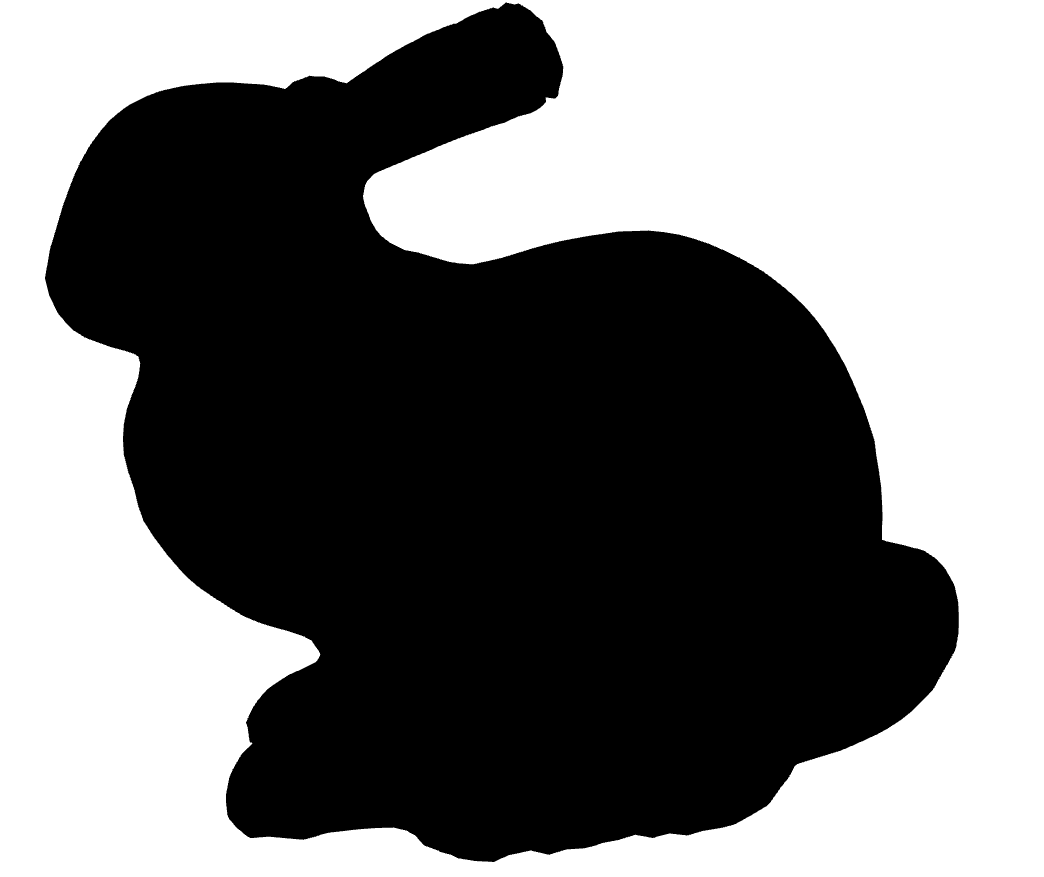

In [52]:
Image(filename="poisson_recon.png")

#### Explanation:

- Poisson treats reconstruction as a volumetric problem, solving for an indicator function of the surface.

- depth controls detail higher = more detail but slower.

## Step 5: Ball Pivoting Reconstruction

In [42]:
# Ball Pivoting reconstruction
radii = [0.005, 0.01, 0.02]  # ball radii for different feature sizes
bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
    pcd,
    o3d.utility.DoubleVector(radii)
)

o3d.visualization.draw_geometries([bpa_mesh], window_name="Ball Pivoting Reconstruction")


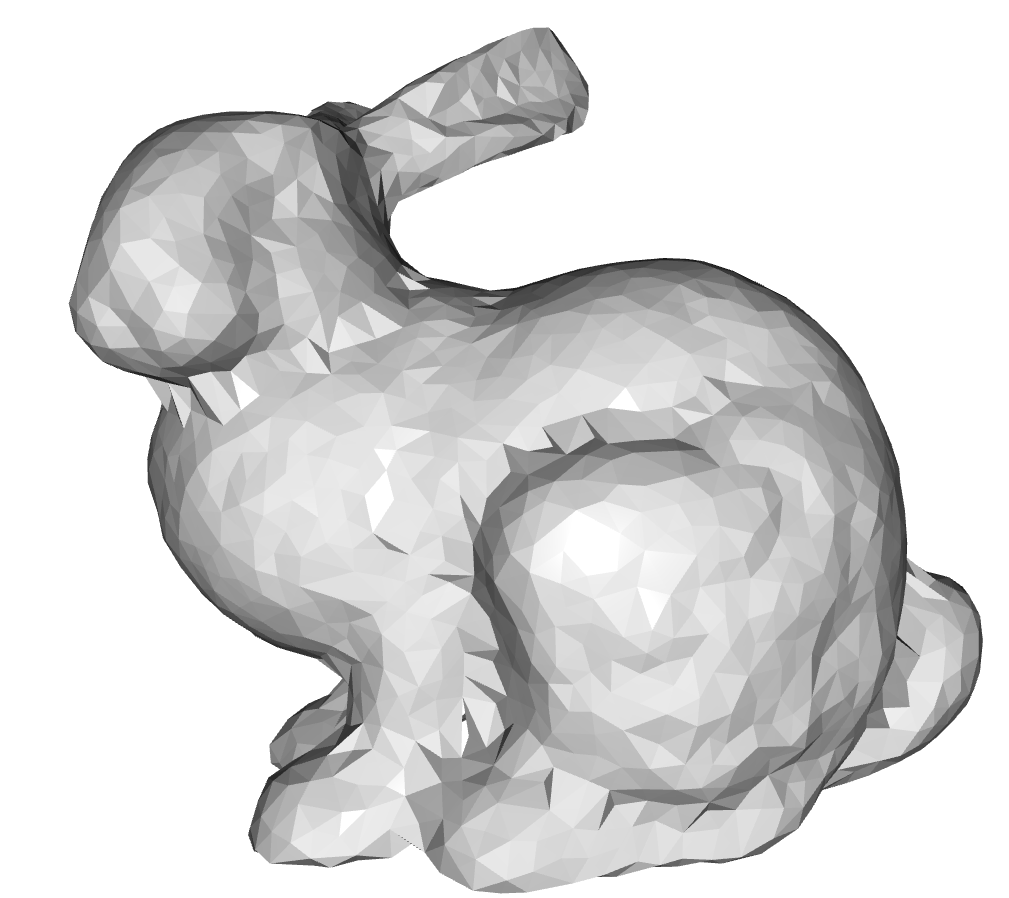

In [53]:
Image(filename="ball_pivot_recon.png")

#### Explanation

- Imagine rolling a ball along the point cloud wherever it touches 3 points, a triangle is formed.
- Good for partial scans and preserves fine features.

## Comparing outputs

In [54]:
print(f"Original points: {len(pcd.points)}")
print(f"Poisson mesh triangles: {len(poisson_mesh.triangles)}")
print(f"BPA mesh triangles: {len(bpa_mesh.triangles)}")
poisson_smoothness = mesh_smoothness(poisson_mesh)
bpa_smoothness = mesh_smoothness(bpa_mesh)

print("Poisson Smoothness:", poisson_smoothness)
print("Ball Pivoting Smoothness:", bpa_smoothness)


Original points: 3000
Poisson mesh triangles: 20546
BPA mesh triangles: 5928
Poisson Smoothness: 0.858
Ball Pivoting Smoothness: 0.863


## Key Takeaways:
- Point clouds are raw data; surface reconstruction turns them into usable 3D models.
- **Poisson** → smooth, watertight, good for closed surfaces.
- **BPA** → preserves details, works with incomplete scans.
- Preprocessing (like sampling) affects final quality.
- Open3D makes it easy to try both methods on the same dataset.
